``AAPredPlot().window()`` draws the per-residue profile from :meth:`AAPred.predict_window`:

In [1]:
import aaanalysis as aa
aa.options["verbose"] = False  # Disable verbosity

df_seq = aa.load_dataset(name="DOM_GSEC")
labels = df_seq["label"].to_list()
df_feat = aa.load_features(name="DOM_GSEC").head(20)

# Training feature matrix
sf = aa.SequenceFeature()
X = sf.feature_matrix(features=df_feat, df_parts=sf.get_df_parts(df_seq=df_seq))

# Bind df_feat so raw sequences are featurized internally by the predict_* methods
aapred = aa.AAPred(df_feat=df_feat, random_state=42)
aapred.fit(X, labels)

row = df_seq[df_seq["entry"] == "P05067"].iloc[0]
tmd_len = int(row["tmd_stop"] - row["tmd_start"] + 1)
df_window = aapred.predict_window(df_seq[df_seq["entry"] == "P05067"][["entry", "sequence"]],
                                  tmd_len=tmd_len, step=3)

/Users/stephanbreimann/Programming/1Packages/wt-prediction-class/aaanalysis/feature_engineering/_backend/cpp_run.py:164: UserWarning: CPP is using the Python kernel fallback — the compiled Cython extension is not available in this install. Output is bit-exact with the Cython path but ~2x slower. Reinstall via `pip install --force-reinstall aaanalysis` to fetch a prebuilt wheel.
  warnings.warn(


The score profile is drawn along the sequence with a decision threshold:

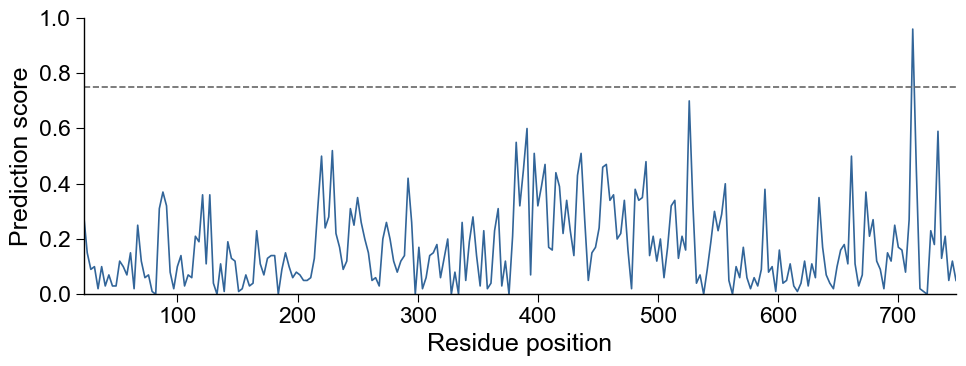

In [2]:
import matplotlib.pyplot as plt
aa.plot_settings()
aapred_plot = aa.AAPredPlot()
aapred_plot.window(df_window, threshold=0.75)
plt.tight_layout()
plt.show()